# 🔬 Feature Engineering & Exploratory Data Analysis (EDA)
## Customer Support Ticket Triage AI

This notebook documents the feature engineering pipeline used to transform raw ticket text into high-dimensional numerical vectors for machine learning.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys
from pathlib import Path
from sklearn.feature_extraction.text import TfidfVectorizer

# Add project root to sys.path
BASE_DIR = Path(os.getcwd()).resolve().parent
sys.path.append(str(BASE_DIR))

from utils.preprocessing import clean_text

# Set design aesthetics
plt.style.use('ggplot')
sns.set_palette("viridis")

### 1. Data Loading & Inspection

In [2]:
DATA_PATH = BASE_DIR / "data" / "tickets.csv"
df = pd.read_csv(DATA_PATH)

print(f"Dataset Size: {df.shape}")
df.head()

Dataset Size: (554, 4)


,ticket_id,description,category,priority
0,1,Important: My transfer was flagged last night....,Billing,High
1,2,I am having trouble with keys when I try to ch...,Account,Critical
2,3,Suggestion: The item is not appearing as expec...,Technical,Low
3,4,The auth settings are actingg strange. I need ...,Account,Low
4,5,Routine: The statement from my last login seem...,Billing,Medium


### 2. Feature 1: Text Cleaning (The 'Whole' Transformation)
Our semantic feature engineering starts with cleaning. This removes noise (punctuation, URLs, digits) while normalizing text (lowercase).

In [3]:
# Original text vs Cleaned text
sample_text = df.iloc[0]['description']
cleaned_sample = clean_text(sample_text)

print(f"Original: {sample_text[:100]}...")
print(f"Cleaned:  {cleaned_sample[:100]}...")

# Apply to whole dataset
df['clean_text'] = df['description'].apply(clean_text)

Original: Important: My transfer was flagged last night. I also have a question about contact email. Thanks fo...
Cleaned:  important my transfer was flagged last night i also have a question about contact email thanks for t...


### 3. Feature 2: Ticket Length (Structural Feature)
Does ticket length correlate with priority or category? Longer tickets often imply more complex 'Technical' issues.

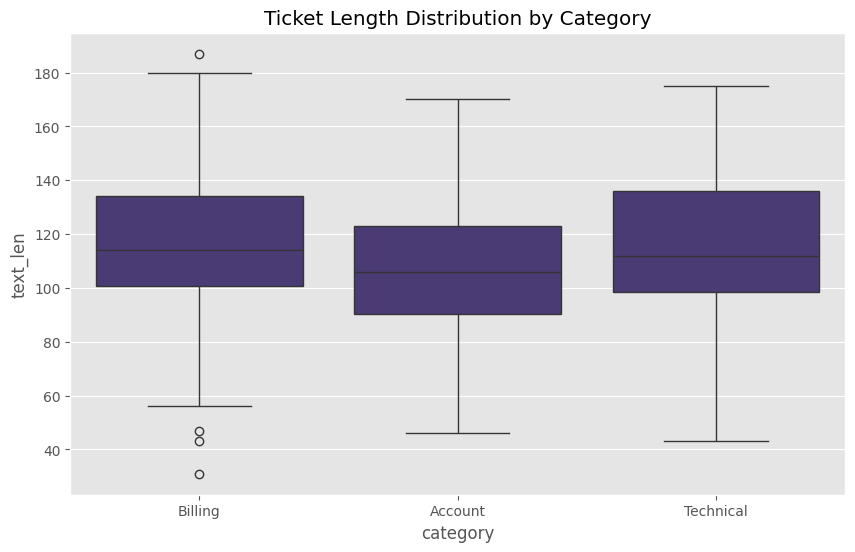

In [4]:
df['text_len'] = df['clean_text'].apply(len)

plt.figure(figsize=(10, 6))
sns.boxplot(x='category', y='text_len', data=df)
plt.title("Ticket Length Distribution by Category")
plt.show()

### 4. Feature 3: TF-IDF Vectorization (N-Grams & Semantic Weights)
We use **Term Frequency-Inverse Document Frequency** to weight tokens. 
- **Unigrams**: Single words (e.g., 'crashing')
- **Bigrams**: Word pairs (e.g., 'login failure') to capture context loss.
- **Stopwords**: Filtered out 'english' noise.

In [5]:
tfidf = TfidfVectorizer(ngram_range=(1, 2), max_features=5000, stop_words='english')
X_tfidf = tfidf.fit_transform(df['clean_text'])

print(f"TF-IDF Feature Matrix Shape: {X_tfidf.shape}")

TF-IDF Feature Matrix Shape: (554, 1759)


### 5. Meta-Feature Analysis: Top Predicting Terms
Let's extract top tokens per category to validate our feature engineering logic.

In [6]:
from sklearn.feature_selection import chi2

features = tfidf.get_feature_names_out()
for category in df['category'].unique():
    labels = (df['category'] == category)
    chi2score = chi2(X_tfidf, labels)[0]
    wscores = zip(features, chi2score)
    wscores = sorted(wscores, key=lambda x: x[1], reverse=True)
    print(f"\n--- Top 10 Features for {category} ---")
    print(wscores[:10])


--- Top 10 Features for Billing ---
[('notification', np.float64(17.09488494908294)), ('night', np.float64(16.140477731645714)), ('says', np.float64(15.83152005544152)), ('night question', np.float64(15.668556354988466)), ('different', np.float64(15.545706945644607)), ('discrepancy', np.float64(15.320058332991103)), ('received notification', np.float64(12.681680726662206)), ('expecting', np.float64(12.412341067769848)), ('received', np.float64(12.031182853678093)), ('behave', np.float64(10.971830426218505))]

--- Top 10 Features for Account ---
[('try', np.float64(16.506236436318737)), ('having trouble', np.float64(15.976761415245866)), ('keeps', np.float64(13.259450216377104)), ('settings', np.float64(12.865314455905185)), ('level', np.float64(12.635672145276832)), ('seeing', np.float64(12.537838315269624)), ('seeing updates', np.float64(12.537838315269624)), ('updates', np.float64(12.537838315269624)), ('insufficient', np.float64(12.37099612265079)), ('level insufficient', np.float6